## 1. Pricing Floors

### Imports and Data Imports

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../Data/cap_curves_2025-06-30.xlsx")
df.head(20)

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
5,1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
6,1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
7,2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
8,2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413
9,2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022


### 1.1 Floorlet
Recall that a floor is a portfolio of floorlets which 
- depend on the realized interest rate one quarter before the expiration.
- each have the same strike interest rate.

Use Black’s formula to price just one floorlet
- expiring at T=3
- struck at the T=3 swap rate
- notional of 100
- quarterly frequency



In [90]:
fowards = df.loc[df['tenor'] == 3.00, "forwards"].values[0]
flat_vol = df.loc[df['tenor'] == 3.00, "flat vols"].values[0]
discounts = df.loc[df['tenor'] == 3.00, "discounts"].values[0]
spot_rate = df.loc[df['tenor'] == 3.00, "spot rates"].values[0]
swap_rate = df.loc[df['tenor'] == 3.00, "swap rates"].values[0]
fwd_vol = df.loc[df['tenor'] == 3.00, "fwd vols"].values[0]
print(f"Forward rate: {fowards}")
print(f"Flat volatility: {flat_vol}")
print(f"Discount factor: {discounts}")
print(f"Spot rate: {spot_rate}")
print(f"Swap rate: {swap_rate}")
print(f"Forward volatility: {fwd_vol}")

Forward rate: 0.03298741875054478
Flat volatility: 0.2946577928241044
Discount factor: 0.904789863917458
Spot rate: 0.03349027440623065
Swap rate: 0.03356821290403046
Forward volatility: 0.2760569572882981


In [91]:
from scipy.stats import norm
d_1 = (np.log(fowards / swap_rate) + 0.5 * flat_vol ** 2 * (3-0.25)) / (flat_vol * np.sqrt(3-0.25))
d_2 = d_1 - flat_vol * np.sqrt(3-0.25)
floor_price = discounts * (swap_rate * norm.cdf(-d_2) - fowards * norm.cdf(-d_1)) * 100/4
print(f"Floor price: {floor_price}")


Floor price: 0.15194879629290148


### 1.2 
- Use Black's formula to price the entire floor with expiration of ```T=3```, each floor has floorlets at quarterly frequency, except the first quarter

In [92]:
expirations = np.arange(0.50, 3.25, 0.25)
expirations 

array([0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 , 2.75, 3.  ])

In [93]:
floor_price = 0
floorlet_df = {"expiration": [], "floorlet_price": []}

for i in range(len(expirations)):
    forwards = df.loc[df['tenor'] == expirations[i], "forwards"].values[0]
    discount = df.loc[df['tenor'] == expirations[i], "discounts"].values[0]
    d_1 = (np.log(forwards / swap_rate) + 0.5 * flat_vol ** 2 * (expirations[i]-0.25)) / (flat_vol * np.sqrt(expirations[i]-0.25))
    d_2 = d_1 - flat_vol * np.sqrt(expirations[i]-0.25)
    floorlet_price = discount * (swap_rate * norm.cdf(-d_2) - forwards * norm.cdf(-d_1)) * 100/4
    floor_price += floorlet_price
    floorlet_df["expiration"].append(expirations[i])
    floorlet_df["floorlet_price"].append(floorlet_price)

floorlet_df = pd.DataFrame(floorlet_df)
print(f"Floor price: {floor_price}")

Floor price: 1.3175550466703734


In [94]:
floorlet_df

,expiration,floorlet_price
0,0.50,0.009368
1,0.75,0.041221
2,1.00,0.075248
3,1.25,0.125061
4,1.50,0.142752
5,1.75,0.147216
6,2.00,0.149793
7,2.25,0.164223
8,2.50,0.156857
9,2.75,0.153865


## 2. Stripping Caps

### 2.1 
For each cap maturity, 0.5 <= T <= 10 use the flat volatility to get the price of the cap.

Report the cap prices across expirations, 0.5 <= T <= 10.

Plot the cap prices across expirations.

In [101]:
def price_caplet(tenor):
    expirations = np.arange(0.50, tenor + 0.25, 0.25)
    cap_price = 0

    for i in range(len(expirations)):
        forwards = df.loc[df['tenor'] == expirations[i], "forwards"].values[0]
        discount = df.loc[df['tenor'] == expirations[i], "discounts"].values[0]
        d_1 = (np.log(forwards / swap_rate) + 0.5 * flat_vol ** 2 * (expirations[i]-0.25)) / (flat_vol * np.sqrt(expirations[i]-0.25))
        d_2 = d_1 - flat_vol * np.sqrt(expirations[i]-0.25)
        caplet_price = discount * (forwards * norm.cdf(d_1) - swap_rate * norm.cdf(d_2)) * 100/4
        cap_price += caplet_price

    return cap_price

In [96]:
cap_price = {"tenor" : [], "cap_price": []}
for i in np.arange(0.50, 10, 0.25):
    cap_price["tenor"].append(i)
    cap_price["cap_price"].append(price_caplet(i))

cap_price["tenor"].append(0.25)
cap_price["cap_price"].append(0)
cap_price = pd.DataFrame(cap_price)
cap_price.sort_values("tenor", inplace=True)
cap_price

,tenor,cap_price
38,0.25,0.000000
0,0.50,0.151026
1,0.75,0.261336
2,1.00,0.352203
3,1.25,0.414429
4,1.50,0.479228
5,1.75,0.555259
6,2.00,0.643194
7,2.25,0.730486
8,2.50,0.837812


### 2.2
Using the cap prices, strip out the

- caplet prices

- forward volatility at $\tau$ which properly prices caplet $\tau$ using Black’s formula.

List and plot the forward volatility versus the flat volatiltiy.



In [97]:
cap_price.set_index("tenor", inplace=True)
caplet_price = cap_price.diff()
caplet_price

,cap_price
tenor,
0.25,NaN
0.50,0.151026
0.75,0.110310
1.00,0.090867
1.25,0.062226
1.50,0.064798
1.75,0.076031
2.00,0.087935
2.25,0.087292


In [102]:
from scipy.stats import norm
from scipy.optimize import brentq
import numpy as np

def black_caplet(sigma, tau, K, f, Z):
    """Black's formula for a single caplet"""
    d1 = (np.log(f/K) + 0.5*sigma**2 * tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return (100/4) * Z * (f*norm.cdf(d1) - K*norm.cdf(d2))

def implied_fwd_vol(caplet_price, tau, K, f, Z):
    """Invert Black's formula to get forward vol"""
    objective = lambda sigma: black_caplet(sigma, tau, K, f, Z) - caplet_price
    return brentq(objective, 1e-6, 10.0)  # search between 0% and 1000% vol


df_concate = caplet_price.merge(df, on="tenor")
df_concate

,tenor,cap_price,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,NaN,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.151026,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.110310,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.090867,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.062226,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
5,1.50,0.064798,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
6,1.75,0.076031,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
7,2.00,0.087935,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
8,2.25,0.087292,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413
9,2.50,0.107325,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022


In [104]:
for caplet in df_concate.iterrows():

    if caplet[1]["tenor"] - 0.25 == 0:
        continue 
    
    derived_forward_vols = implied_fwd_vol(caplet[1]["cap_price"], caplet[1]["tenor"] - 0.25, caplet[1]["swap rates"], caplet[1]["forwards"], caplet[1]["discounts"])
    df_concate.at[caplet[0], 'derived_forward_vol'] = derived_forward_vols

df_concate


,tenor,cap_price,swap rates,spot rates,discounts,forwards,flat vols,fwd vols,derived_forward_vol
0,0.25,NaN,0.042353,0.042353,0.989523,NaN,NaN,NaN,NaN
1,0.50,0.151026,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842,0.868531
2,0.75,0.110310,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708,0.556951
3,1.00,0.090867,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464,0.443788
4,1.25,0.062226,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341,0.370969
5,1.50,0.064798,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521,0.340439
6,1.75,0.076031,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809,0.323525
7,2.00,0.087935,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654,0.312601
8,2.25,0.087292,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413,0.302718
9,2.50,0.107325,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022,0.298085


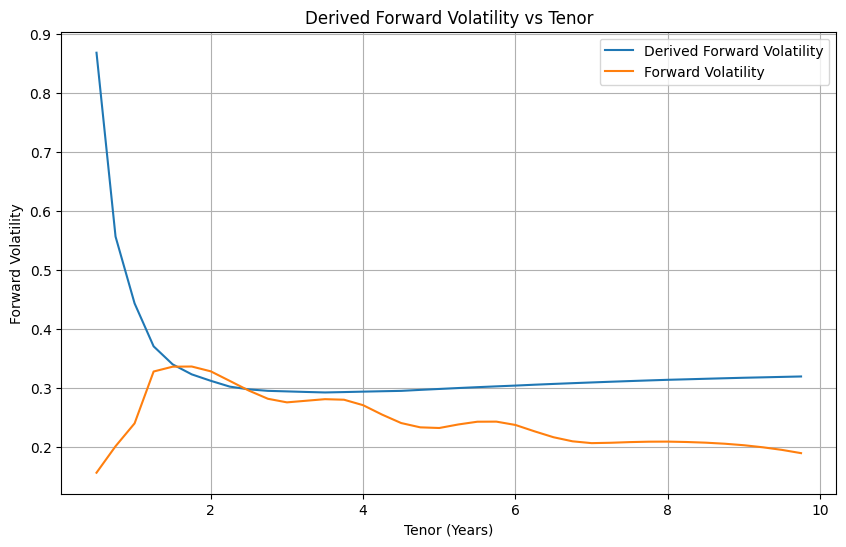

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(df_concate["tenor"], df_concate["derived_forward_vol"], label="Derived Forward Volatility")
plt.plot(df_concate["tenor"], df_concate["fwd vols"], label="Forward Volatility")
plt.xlabel("Tenor (Years)")
plt.ylabel("Forward Volatility")
plt.title("Derived Forward Volatility vs Tenor")
plt.legend()
plt.grid(True)
